In [108]:
import numpy as np

def cf_shell(label="shell",
             total_time=20,
             time_step=0.25/30,
             b=0.1, d=4, z=0, a=1, phi=0, psi=0,
             n=0, n_amp=0,
             c=0, c_amp=0,
             k=0, 
             points_on_aperture=1,
             length=1,
             smooth=True):
    
    times = np.arange(start=0, stop=total_time, step=time_step)
    
    sin_t = np.sin(times)
    cos_t = np.cos(times)
    axial_term = 1 + c_amp * np.sin(c * times)
    spiral_term = (np.exp(b * times) - (1 / (times + 1)))
    spiral_term = spiral_term[..., np.newaxis].T

    gamma_exp = np.exp(b*times)[..., np.newaxis]
    gamma_vec = np.array([
        d*sin_t,
        d*cos_t,
        z
    ])[..., np.newaxis].T

    gamma = gamma_exp*gamma_vec

    R = np.array([[np.cos(psi), -np.sin(psi), 0],
                  [np.sin(psi), np.cos(psi), 0],
                  [0, 0, 1]])

    # Normal and Binormal vectors without modifying their structures
    _N = np.array([
        b * cos_t - sin_t,
        -b * sin_t - cos_t,
        0  # This maintains the 3-component structure
    ]) / np.sqrt(b**2 + 1)
    _N = _N[..., np.newaxis]

    _B = np.array([
        b * z * (b * sin_t + cos_t),
        b * z * (b * cos_t - sin_t),
        d * (b**2 + 1)  # This maintains the 3-component structure
    ]) / np.sqrt((b**2 + 1) * ((b**2 + 1) * d**2 + b**2 * z**2))
    _B = _B[..., np.newaxis]
    
    #Compute the transformation for current t
    C = spiral_term*np.matmul(R, 
                         (a * np.sin(phi) + np.cos(phi)) * spiral_term * _N + \
                         (a * np.sin(phi) - np.cos(phi) + k) * spiral_term * _B)

    lam = gamma + C.T
    return lam


In [111]:
# Assume cf_shell outputs a 2400 x 80 x 3 tensor
data = cf_shell(b=0.06, z=5, points_on_aperture=1)
data.shape

C:\Users\caleb\AppData\Local\Temp\ipykernel_20080\1769805421.py:23: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  gamma_vec = np.array([
C:\Users\caleb\AppData\Local\Temp\ipykernel_20080\1769805421.py:36: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  _N = np.array([
C:\Users\caleb\AppData\Local\Temp\ipykernel_20080\1769805421.py:43: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must speci

(2400, 3)

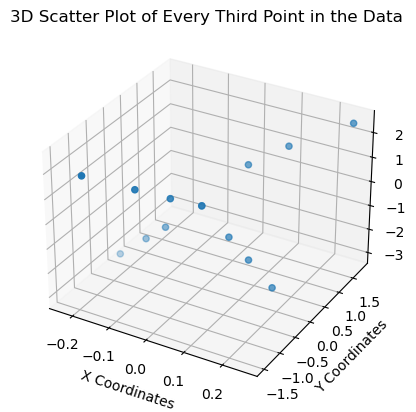

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Assuming 'data' is a numpy array with shape (n, n, 3) that holds xyz coordinates

# Create a figure for 3D plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Extracting every third element
x = data[::3, ::3, 0].flatten()
y = data[::3, ::3, 1].flatten()
z = data[::3, ::3, 2].flatten()

# Scatter plot for the points
ax.scatter(x, y, z)

# Setting labels
ax.set_xlabel('X Coordinates')
ax.set_ylabel('Y Coordinates')
ax.set_zlabel('Z Coordinates')
plt.title('3D Scatter Plot of Every Third Point in the Data')
plt.show()
